In [ ]:
! pip install openvino ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.9 MB/s eta 0:00:00


In [ ]:
# import pickle
import cv2
import numpy as np
from keras.models import load_model
import tensorflow as tf
import openvino as ov


freshness_model = r"/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/mobileapp models/sardine/sardine.xml"
fish_model = r'/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/mobileapp models/best_openvino_model'
cuts_model = r'/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/mobileapp models/cut-seg_openvino_model'

# Initialize OpenVINO Core
core = ov.Core()

# Load Model
try:
    ov_model = core.read_model(freshness_model)
    ov_model.reshape({ov_model.inputs[0]: [1, 224, 224, 3]})
    model = ov.compile_model(ov_model)
except:
    # Note: Ensure this path points to a keras model if using load_model,
    # otherwise loading .xml with keras might fail.
    model = load_model(freshness_model)

target_size = (224, 224)
threshold = 0.5 # 0.478963

def inference_ov_async(infer_request, image):
    """
    Set the input tensor data using the provided image (converted to numpy),
    start asynchronous inference, wait for completion, and return the prediction.
    """
    input_tensor = infer_request.get_input_tensor()
    input_tensor.data[:] = image  # Convert TensorFlow tensor to numpy array
    infer_request.start_async()
    infer_request.wait()  # Wait for inference to complete
    return infer_request.get_output_tensor().data[0][0]

def inference_model(model, image):
    """
    Perform inference using asynchronous mode if OpenVINO is used; otherwise, fall back to synchronous inference.
    """
    output_layer_name = list(model.outputs[0].names)[0]
    try:
        # Use the asynchronous inference approach using the first request
        prediction = inference_ov_async(model.create_infer_request(), image)
        # print("With ASYNC inference") # Optional: Uncomment if you want to verify async usage
    except:
        print("Using synchronous inference")
        result = model(image)
        prediction = result[output_layer_name][0][0]
    return prediction

def process_image(image):
    """
    Resize and preprocess the input image.
    """
    resized_image = cv2.resize(image, target_size)
    processed_image = tf.keras.applications.densenet.preprocess_input(resized_image)
    processed_image = tf.expand_dims(processed_image, axis=0)
    return processed_image

def predict_sardine(image):
    """
    Process the input image, run inference, and return a label based on the threshold.
    """
    processed = process_image(image)
    pred = inference_model(model, processed)
    label = 'Good' if pred >= threshold else 'Bad'

    # Printed to stdout for Notebook visibility
    # print(f"Sardine Model Predicted --> Label: {label} , Confidence : {pred}")
    return label

# Warm-up routine
dummy_image = np.zeros((1, 224, 224, 3), dtype=np.float32)
try:
    inference_model(model, dummy_image)
    print("✅ Sardine model warm-up complete.")
except Exception as e:
    print(f"Error during warm-up: {e}")

✅ Sardine model warm-up complete.


In [ ]:
import numpy as np
from PIL import Image
import cv2
import tensorflow as tf
from keras.models import load_model
import base64
from ultralytics import YOLO
import io

# Initialize YOLO models
try:
    yolo = YOLO(fish_model, task='segment')
    cut = YOLO(cuts_model, task='segment')

    # Warm-up routine
    dummy_image = np.zeros((640, 640, 3), dtype=np.uint8)
    yolo.predict(dummy_image, verbose=False)
    cut.predict(dummy_image, verbose=False)
    print("✅ YOLO detection models warm-up complete.")
except Exception as e:
    print(f"Error loading YOLO models from local path: {e}")


def extract_single_image_segment(img, mask_segment, shape, background='black'):
    """
    Extracts a specific segment from an image based on the provided mask.

    Args:
    - img: The original image.
    - mask_segment: The mask coordinates defining the segment to extract.
    - shape: The shape of the original image (height, width).
    - background: The background color for the extracted segment ('black' or 'white').

    Returns:
    - segment_image: The extracted image segment with the specified background.
    """
    height, width = shape[0], shape[1]
    segment = np.array(mask_segment, dtype=np.int32)
    segment = segment.reshape((-1, 2))
    mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(mask, [segment], 255)
    masked_img = cv2.bitwise_and(img, img, mask=mask)
    x, y, w, h = cv2.boundingRect(segment)
    segment_image = np.zeros((h, w, 3), dtype=np.uint8)
    segment_image[0:h, 0:w] = masked_img[y:y+h, x:x+w]

    if background.lower() == 'black':
        black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
        segment_image[black_mask] = [0, 0, 0]  # Set background to black
    elif background.lower() == 'white':
        black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
        segment_image[black_mask] = [255, 255, 255]  # Set background to white
    else:
        raise ValueError("Invalid background color. Use 'black' or 'white'.")

    return segment_image

def process_image2(image, size=(640, 640)): # for eye model
    """
    Pre-process the image for the damage detection model.
    Resizes and pads the image to the specified size while maintaining aspect ratio.
    """
    h, w = image.shape[:2]
    aspect_ratio = w / h
    if aspect_ratio > 1:
        new_w = size[0]
        new_h = int(new_w / aspect_ratio)
    else:
        new_h = size[1]
        new_w = int(new_h * aspect_ratio)

    resized_image = cv2.resize(image, (new_w, new_h))

    pad_h = (size[1] - new_h) // 2
    pad_w = (size[0] - new_w) // 2
    padded_image = cv2.copyMakeBorder(
        resized_image, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_CONSTANT, value=(255, 255, 255)
    )
    padded_image = cv2.resize(padded_image, (640,640))
    return np.asarray(padded_image)


def is_cut(image, conf=0.5):
    """
    Detect if the fish in the image has cuts or damages using the YOLO model.

    Args:
    - image: The input image.
    - conf: Confidence threshold for detection.

    Returns:
    - True if damage is detected, False otherwise.
    """
    img = image[:,:,::-1]
    res = cut.predict(img, conf=conf)
    if len(res[0].boxes.xyxy) == 0:
        return False
    else:
        return True

def return_mask(image, masks, labels, boxes):
    """
    Draw masks and labels on the image based on detection results.

    Args:
    - image: The original image.
    - masks: List of masks for detected objects.
    - labels: List of labels corresponding to detected objects.
    - boxes: List of bounding boxes for detected objects.

    Returns:
    - image_with_masks: The image with drawn masks and labels.
    """
    # Ensure the image is writable by creating a copy
    writable_image = np.copy(image)

    mask_image = np.zeros_like(writable_image)

    height, width, _ = writable_image.shape

    for mask, label, box in zip(masks, labels, boxes):
        xmin, ymin, xmax, ymax = list(map(int, box))

        # Calculate the thickness and text size based on image dimensions
        thickness = max(int(min(height, width) / 200), 1)
        text_size = max(int(min(height, width) / 800), 1)

        if 'good' in label.lower():
            color = (0, 255, 0)  # Green mask
        elif 'ok' in label.lower():
            color = (255, 255, 0)  # Yellow mask
        else:
            color = (255, 0, 0)  # Red mask

        mask_coords = np.array(mask, dtype=np.int32)
        cv2.fillPoly(mask_image, [mask_coords], color)
        cv2.rectangle(writable_image, (xmin, ymin), (xmax, ymax), color, thickness)
        cv2.putText(writable_image, label, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, text_size, color, thickness)

    alpha = 0.2  # Transparency level for the mask
    image_with_masks = cv2.addWeighted(writable_image, 1 - alpha, mask_image, alpha, 0)
    image_with_masks = cv2.cvtColor(image_with_masks, cv2.COLOR_BGR2RGB)
    return image_with_masks


def freshness_prediction(image, w_mask_image, b_mask_image, fish, box):
    """
    Predict the freshness of a fish based on its appearance and characteristics.

    Args:
    - image: Original image containing the fish.
    - w_mask_image: Image segment with white background.
    - b_mask_image: Image segment with black background.
    - fish: Species of the fish.
    - box: Bounding box coordinates of the fish.

    Returns:
    - label: Freshness label ('Good' or 'Bad').
    - reason: Reason for the freshness label, if any.
    """
    # Check the species of the fish and perform freshness prediction accordingly
    damage = is_cut(process_image2(w_mask_image), conf=0.85)
    if damage:
        return 'Bad', 'Damaged'

    # Predict freshness based on sardine-specific model
    # Note: Ensure predict_sardine is imported or available in this scope
    pred = predict_sardine(b_mask_image)
    if pred == 'Bad':
        return pred, 'Softness'
    else:
        return pred, None


def final_prediction(image, species, model):
    """
    Perform final prediction on the given image for a specific species using a specified model.

    Args:
    - image: Image file path or image data (numpy array).
    - species: Species label for classification.
    - model: Model name ('fish' or 'prawn').

    Returns:
    - result: A dictionary containing the prediction results.
    """
    result = dict()
    top3 = []

    # Open image and convert it to numpy array
    try:
        img = Image.open(image)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        img_byte_arr = io.BytesIO()
        img.save(img_byte_arr, format=img.format)
        img_byte_arr = img_byte_arr.getvalue()
        img_from_bytes = Image.open(io.BytesIO(img_byte_arr))
        image = np.asarray(img_from_bytes)
    except Exception as e:
        return None

    shape = image.shape

    # Perform object detection based on model
    if model.lower() == 'fish':
        pred = yolo.predict(image[:, :, ::-1], conf=0.75)
        if len(pred[0].boxes.xyxy) == 0 :
            return None

    # Extract bounding boxes and masks
    boxes = pred[0].boxes.xyxy
    masks = pred[0].masks.xy
    filtered_boxes = sorted(boxes, key=lambda bbox: bbox[0])
    sorted_masks = [masks[i] for i in sorted(range(len(masks)), key=lambda x: boxes[x][0])]

    new_labels = []
    reasons = []
    i = 0

    # Iterate over each detected box and mask
    for box, mask in zip(filtered_boxes, sorted_masks):
        i += 1
        xmin, ymin, xmax, ymax = list(map(int, box))
        extracted_image = image[ymin:ymax, xmin:xmax]

        # Perform freshness prediction
        w_mask_image = extract_single_image_segment(image, mask, shape=shape, background='white')
        b_mask_image = extract_single_image_segment(image, mask, shape=shape, background='black')
        L, R = freshness_prediction(image, w_mask_image, b_mask_image, species, box)

        # Construct label for the prediction
        v = str(i) + '-' + str(L)
        if R is not None:
            v += '-' + str(R)
        reasons.append(R)
        new_labels.append(v)

    # Generate output image with labels
    output_image = return_mask(image, sorted_masks, new_labels, filtered_boxes)
    _, image_bytes = cv2.imencode('.jpg', output_image)
    encoded_string = base64.b64encode(image_bytes).decode('utf-8')

    # Count good and bad predictions
    good = 0
    bad = 0
    for i in range(len(new_labels)):
        fresh = new_labels[i].split('-')[1]
        top3.append(fresh)
        if fresh.lower() == 'good':
            good += 1
        else:
            bad += 1

    # Construct result dictionary
    result['fishes-detected'] = good + bad
    result['good-fishes'] = good
    result['bad-fishes'] = bad
    result['reasons'] = reasons
    result['image-encode'] = encoded_string
    result['classification'] = 'True'
    result['species'] = species
    result['first3'] = top3
    return result

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading /content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/mobileapp models/best_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on CPU...
Loading /content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/mobileapp models/cut-seg_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on CPU...
✅ YOLO detection models warm-up complete.


In [ ]:
incorrect_image_files[:3]

[PosixPath('/content/drive/MyDrive/Sowmya /input/2025-01-21/sardine/Good/2025-01-21_10_18_01_(18776)_sardine_input.jpeg'),
 PosixPath('/content/drive/MyDrive/Sowmya /input/2025-01-21/sardine/Good/2025-01-21_10_22_22_(18794)_sardine_input.jpeg'),
 PosixPath('/content/drive/MyDrive/Sowmya /input/2025-01-21/sardine/Good/2025-01-21_10_19_34_(18781)_sardine_input.jpeg')]

In [ ]:
image_path = incorrect_image_files[0]
result = final_prediction(
    image=str(image_path),
    species="sardine",
    model="fish"
)

print(result is not None)

True


In [ ]:
predictions = result.get("first3", [])
reasons = result.get("reasons", [])
predictions, reasons

(['Good', 'Good'], [None, None])

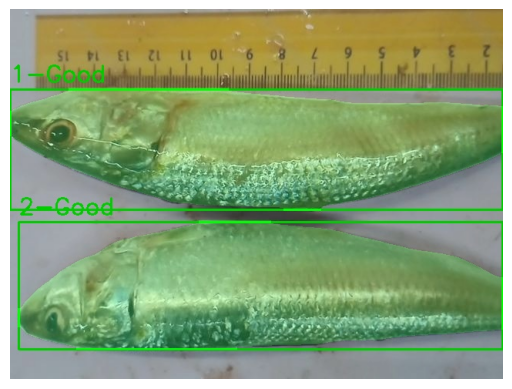

In [ ]:
## show the encoded image
import base64, cv2
import numpy as np
import matplotlib.pyplot as plt

encoded_string = result['image-encode']
image_bytes = base64.b64decode(encoded_string)
image_array = np.frombuffer(image_bytes, dtype=np.uint8)
image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.axis('off');
plt.show();

In [ ]:
from tqdm import tqdm
import os
import pandas as pd
from pathlib import Path
from typing import List, Dict, Optional

def build_freshness_evaluation_df(
    root_dir: str,
    species: str = "sardine",
    model_type: str = "fish",
    valid_exts: Optional[List[str]] = None
) -> pd.DataFrame:
    """
    Run batch inference on a folder of images and return a structured DataFrame
    containing per-fish predictions.

    Progress bar shows evaluation status across images.

    Parameters
    ----------
    root_dir : str
        Path to the root input directory (e.g., "input/").
    species : str, default="sardine"
        Species name passed to the freshness pipeline.
    model_type : str, default="fish"
        Model type passed to `final_prediction`.
    valid_exts : list[str], optional
        Allowed image extensions.

    Returns
    -------
    pd.DataFrame
        Fish-level prediction DataFrame.
    """

    if valid_exts is None:
        valid_exts = [".jpg", ".jpeg", ".png", ".bmp"]

    rows: List[Dict] = []
    root_dir = Path(root_dir)

    if not root_dir.exists():
        raise FileNotFoundError(f"Input directory does not exist: {root_dir}")

    # Collect all valid image files first (for tqdm total)
    image_files = [
        p for p in root_dir.rglob("*")
        if p.suffix.lower() in valid_exts
        and p.parent.name.lower() in {"good", "bad"}
    ]

    for image_path in tqdm(
        image_files,
        desc="Evaluating images",
        unit="image"
    ):
        actual_class = image_path.parent.name.lower()

        try:
            result = final_prediction(
                image=str(image_path),
                species=species,
                model=model_type
            )
        except Exception:
            continue

        if result is None:
            continue

        predictions = result.get("first3", [])
        reasons = result.get("reasons", [])

        base_name = image_path.name
        filename_id = base_name.split("_")[4]

        for idx, pred_class in enumerate(predictions, start=1):
            fish_filename = f"{filename_id}_({idx})"

            reason = reasons[idx - 1] if idx - 1 < len(reasons) else None

            rows.append({
                "date": base_name.split("_")[0],
                "filename": base_name,
                "filename_id": fish_filename,
                "actual_class": actual_class.capitalize(),
                "predicted_class": pred_class.capitalize(),
                "reason": reason
            })

    return pd.DataFrame(
        rows,
        columns=[
            "date",
            "filename",
            "filename_id",
            "actual_class",
            "predicted_class",
            "reason"
        ]
    )

In [ ]:
df = build_freshness_evaluation_df(
    root_dir="/content/drive/MyDrive/Sowmya /input",
    species="sardine",
    model_type="fish"
)

df.head()

Evaluating images: 100%|██████████| 653/653 [36:17<00:00,  3.33s/image]


,date,filename,filename_id,actual_class,predicted_class,reason
0,2025-01-21,2025-01-21_10_16_46_(18770)_sardine_input.jpeg,(18770)_(1),Good,Good,None
1,2025-01-21,2025-01-21_10_16_46_(18770)_sardine_input.jpeg,(18770)_(2),Good,Good,None
2,2025-01-21,2025-01-21_10_22_30_(18795)_sardine_input.jpeg,(18795)_(1),Good,Good,None
3,2025-01-21,2025-01-21_10_22_30_(18795)_sardine_input.jpeg,(18795)_(2),Good,Good,None
4,2025-01-21,2025-01-21_10_18_01_(18776)_sardine_input.jpeg,(18776)_(1),Good,Good,None


In [ ]:
df.to_csv("/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/sardine_prod_testing/prod_flow_sardine_results.csv", index=False)

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/sardine_prod_testing/prod_flow_sardine_results.csv")

In [ ]:
df

,date,filename,filename_id,actual_class,predicted_class,reason
0,2025-01-21,2025-01-21_10_16_46_(18770)_sardine_input.jpeg,(18770)_(1),Good,Good,NaN
1,2025-01-21,2025-01-21_10_16_46_(18770)_sardine_input.jpeg,(18770)_(2),Good,Good,NaN
2,2025-01-21,2025-01-21_10_22_30_(18795)_sardine_input.jpeg,(18795)_(1),Good,Good,NaN
3,2025-01-21,2025-01-21_10_22_30_(18795)_sardine_input.jpeg,(18795)_(2),Good,Good,NaN
4,2025-01-21,2025-01-21_10_18_01_(18776)_sardine_input.jpeg,(18776)_(1),Good,Good,NaN
...,...,...,...,...,...,...
1240,2024-12-26,2024-12-26_09_29_11_(18171)_sardine_input.jpeg,(18171)_(2),Good,Good,NaN
1241,2024-12-26,2024-12-26_09_35_47_(18207)_sardine_input.jpeg,(18207)_(1),Good,Good,NaN
1242,2024-12-26,2024-12-26_09_35_47_(18207)_sardine_input.jpeg,(18207)_(2),Good,Good,NaN
1243,2024-12-26,2024-12-26_09_31_08_(18177)_sardine_input.jpeg,(18177)_(1),Good,Good,NaN


In [ ]:
"""
evaluation_metrics.py

Utilities for computing and visualizing classification metrics
for fish freshness evaluation.

Author: Your Name
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report


def plot_confusion_matrix(
    y_true,
    y_pred,
    labels=("Good", "Bad"),
    normalize=False,
    title="Confusion Matrix",
    cmap=plt.cm.Blues
):
    """
    Plot a confusion matrix with optional normalization.

    Parameters
    ----------
    y_true : array-like
        Ground truth labels.
    y_pred : array-like
        Predicted labels.
    labels : tuple, default=("Good", "Bad")
        Label order for the confusion matrix.
    normalize : bool, default=False
        If True, normalize confusion matrix by row (true labels).
    title : str
        Plot title.
    cmap : matplotlib colormap
        Colormap used for plotting.
    """

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
        cm = np.nan_to_num(cm)
        title += " (Normalized)"

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation="nearest", cmap=cmap)
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        ylabel="Actual Label",
        xlabel="Predicted Label",
        title=title
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2.0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                format(cm[i, j], fmt),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    fig.tight_layout()
    plt.show()


def print_classification_metrics(
    df,
    actual_col="actual_class",
    pred_col="predicted_class",
    labels=("Good", "Bad")
):
    """
    Print classification metrics using sklearn.

    Parameters
    ----------
    df : pd.DataFrame
        Evaluation DataFrame.
    actual_col : str
        Column name containing ground truth labels.
    pred_col : str
        Column name containing predicted labels.
    labels : tuple
        Class label order.
    """

    y_true = df[actual_col]
    y_pred = df[pred_col]

    print("\n📊 Classification Report")
    print("-" * 60)
    print(
        classification_report(
            y_true,
            y_pred,
            labels=list(labels),
            target_names=list(labels),
            digits=2
        )
    )

    print("\n📊 Confusion Matrix")
    print("-" * 60)
    plot_confusion_matrix(y_true, y_pred, labels=labels)



📊 Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

        Good       0.80      0.85      0.82       793
         Bad       0.71      0.62      0.66       452

    accuracy                           0.77      1245
   macro avg       0.75      0.74      0.74      1245
weighted avg       0.76      0.77      0.76      1245


📊 Confusion Matrix
------------------------------------------------------------


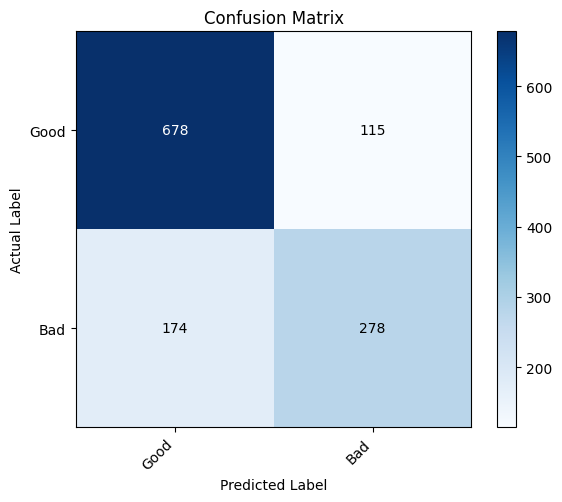

In [ ]:
# Print metrics
print_classification_metrics(df)

Loading Feedback table from database...


/tmp/ipython-input-2314545439.py:74: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Enriching and cleaning DataFrame...

		tp: 609, fn: 223, fp: 112, tn: 363

              precision    recall  f1-score   support

        Good       0.84      0.73      0.78       832
         Bad       0.62      0.76      0.68       475

    accuracy                           0.74      1307
   macro avg       0.73      0.75      0.73      1307
weighted avg       0.76      0.74      0.75      1307



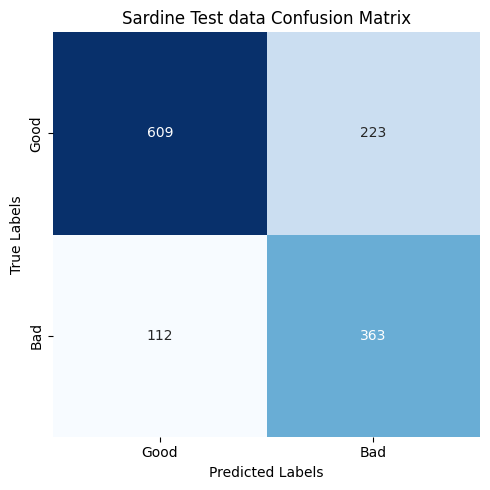

In [ ]:
"""
app_testing_results_analysis.py

End-to-end pipeline for:
- Fetching feedback data from a PostgreSQL database
- Cleaning and enriching the data
- Filtering by date/species/user
- Computing confusion matrices and classification metrics
- Plotting confusion matrices

Designed to be run as a standalone script or imported as a module.
"""

from __future__ import annotations

import os
from dataclasses import dataclass
from typing import Dict, Iterable, List, Optional, Sequence, Tuple
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import psycopg2
from psycopg2.extensions import connection as PGConnection
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# =============================================================================
# Configuration
# =============================================================================


@dataclass
class DBConfig:
    """
    Configuration for connecting to the PostgreSQL database.
    """

    dbname: str = "postgres"
    user: str = "mobileapi2"
    password: str = "mobileapi2"
    host: str = "mobileapi2.c5gmcqq8k94k.ap-south-1.rds.amazonaws.com"
    port: str = "5432"


# =============================================================================
# Database utilities
# =============================================================================


def get_pg_connection(config: DBConfig) -> PGConnection:
    """
    Create and return a PostgreSQL connection using the given configuration.
    """
    conn = psycopg2.connect(
        dbname=config.dbname,
        user=config.user,
        password=config.password,
        host=config.host,
        port=config.port,
    )
    return conn


def load_feedback_table(config: DBConfig) -> pd.DataFrame:
    """
    Load the entire 'Feedback' table from PostgreSQL into a pandas DataFrame.
    """
    conn = get_pg_connection(config)
    try:
        query = 'SELECT * FROM "Feedback"'
        df = pd.read_sql(query, conn)
    finally:
        conn.close()
    return df


# =============================================================================
# URL parsing & Data enrichment
# =============================================================================


def parse_input_image_url(url: str) -> Tuple[str, str, str, str]:
    """
    Parse an input_image_url and return (date, species, filename, filename_id).

    Assumptions (matching current S3 naming logic):
    - Date is the penultimate segment in the URL path.
    - Filename is the basename of the URL path.
    - Species is the penultimate underscore-separated token in the filename.
    - Filename ID is the third underscore-separated token in the filename.

    Example
    -------
    url = ".../2023-11-23/2023-11-23_09:41:35_(2184)_sardine_input.jpeg"

    Returns
    -------
    date : str          -> "2023-11-23"
    species : str       -> "sardine"
    filename : str      -> "2023-11-23_09:41:35_(2184)_sardine_input.jpeg"
    filename_id : str   -> "(2184)"
    """
    # Date from penultimate path segment
    date = url.split("/")[-2]

    # Filename from URL
    parsed_url = urlparse(url)
    object_key = parsed_url.path[1:]  # strip leading "/"
    filename = os.path.basename(object_key)

    # Species from filename (penultimate underscore token)
    parts = filename.split("_")
    species = parts[-2] if len(parts) >= 2 else ""

    # Filename ID from filename (3rd underscore token)
    filename_id = parts[2][1:-1] if len(parts) >= 3 else ""

    return date, species, filename, filename_id


def enrich_feedback_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Enrich the Feedback DataFrame with additional derived columns.

    Adds:
    - Date
    - Species
    - filename
    - filename_id

    Also removes:
    - Rows where user_name equals 'test'
    - Rows where user_name is null
    - Duplicate filename_id rows (keeps first)
    """
    df = df.copy()

    parsed = df["input_image_url"].apply(parse_input_image_url)
    df["Date"] = parsed.apply(lambda x: x[0])
    df["Species"] = parsed.apply(lambda x: x[1])
    df["filename"] = parsed.apply(lambda x: x[2])
    df["filename_id"] = parsed.apply(lambda x: x[3])

    df = df[df["user_name"] != "test"]
    df = df.dropna(subset=["user_name"])
    df = df.drop_duplicates(subset="filename_id", keep="first")

    return df


# =============================================================================
# Generic filtering utilities
# =============================================================================


def filter_df(
    df: pd.DataFrame, filters: Optional[Dict[str, Iterable]] = None
) -> pd.DataFrame:
    """
    Filter a pandas DataFrame based on specified conditions for each column.
    """
    if not filters:
        return df

    filtered = df.copy()
    for col, vals in filters.items():
        if not isinstance(vals, (list, tuple, set, np.ndarray)):
            vals = [vals]
        filtered = filtered[filtered[col].isin(vals)]

    return filtered

def get_unique_values(df: pd.DataFrame, column_names: Sequence[str]) -> Dict[str, List]:
    """
    Get unique values for a list of column names in a DataFrame.
    """
    unique_values_dict: Dict[str, List] = {}
    for col in column_names:
        unique_values_dict[col] = df[col].unique().tolist()
    return unique_values_dict


# =============================================================================
# Metrics & confusion matrix utilities
# =============================================================================


def build_confusion_matrix(df: pd.DataFrame) -> np.ndarray:
    """
    Construct a confusion matrix for Good/Bad classification across fish1/2/3.
    """
    actual_values = df[
        ["fish1_actual", "fish2_actual", "fish3_actual"]
    ].values.flatten()
    predicted_values = df[["fish1_pred", "fish2_pred", "fish3_pred"]].values.flatten()

    actual_values = actual_values[actual_values != None]  # noqa: E711
    predicted_values = predicted_values[predicted_values != None]  # noqa: E711

    labels = ["G", "B"]
    cm = confusion_matrix(actual_values, predicted_values, labels=labels)
    return cm


def pretty_print_confusion_matrix(cm: np.ndarray, species: str) -> None:
    """
    Print a human-readable confusion matrix with labels.
    """
    conf_df = pd.DataFrame(
        cm,
        index=["Actual Good", "Actual Bad"],
        columns=["Predicted Good", "Predicted Bad"],
    )
    print("\n" + "\t" * 3, f"{species} results\n")
    print(conf_df)


def print_classification_report_from_cm(cm: np.ndarray) -> None:
    """
    Compute and print a classification report from a 2x2 confusion matrix.
    """
    tp, fn, fp, tn = cm.ravel()
    print(f"\n\t\ttp: {tp}, fn: {fn}, fp: {fp}, tn: {tn}\n")

    true_labels = [0] * (tp + fn) + [1] * (fp + tn)
    predicted_labels = [0] * tp + [1] * fn + [0] * fp + [1] * tn

    report = classification_report(
        true_labels,
        predicted_labels,
        target_names=["Good", "Bad"],
        zero_division=1,
    )
    print(report)


def plot_confusion_matrix(
    cm: np.ndarray,
    class_labels: Sequence[str],
    title: str = "Confusion Matrix",
) -> None:
    """
    Plot a confusion matrix heatmap and print the associated classification report.
    """
    print_classification_report_from_cm(cm)

    num_labels = len(class_labels)
    fig_size = max(5, num_labels)

    plt.figure(figsize=(fig_size, fig_size))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=class_labels,
        yticklabels=class_labels,
    )
    plt.title(title)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.tight_layout()
    plt.show()


# =============================================================================
# High-level workflow helpers
# =============================================================================


def filter_by_species_and_dates(
    df: pd.DataFrame,
    species: str,
    date_range: Optional[Tuple[str, str]] = None,
) -> pd.DataFrame:
    """
    Filter the DataFrame by species and optional inclusive date range.
    """
    filters: Dict[str, Iterable] = {"Species": [species]}

    if date_range is not None:
        start_date, end_date = date_range
        all_dates = sorted(df["Date"].unique())
        date_list = [d for d in all_dates if start_date <= d <= end_date]
        filters["Date"] = date_list

    return filter_df(df, filters)


def analyze_species(
    df: pd.DataFrame,
    species: str,
    date_range: Optional[Tuple[str, str]] = None,
    plot_title: Optional[str] = None,
) -> None:
    """
    Run the full analysis pipeline for a given species and optional date range.
    """
    result_df = filter_by_species_and_dates(df, species=species, date_range=date_range)
    if result_df.empty:
        print(f"No data found for species={species} and date_range={date_range}")
        return

    cm = build_confusion_matrix(result_df)
    # pretty_print_confusion_matrix(cm, species=species)

    if plot_title is None:
        plot_title = f"{species.capitalize()} Test data Confusion Matrix"

    plot_confusion_matrix(cm, ["Good", "Bad"], title=plot_title)


# =============================================================================
# Main entry point
# =============================================================================


def main() -> None:
    """
    Default script entry point.
    """
    config = DBConfig()
    print("Loading Feedback table from database...")
    df_raw = load_feedback_table(config)

    print("Enriching and cleaning DataFrame...")
    df = enrich_feedback_dataframe(df_raw)

    # Example analysis
    date_range = ("2024-12-02", "2025-01-31")
    analyze_species(
        df,
        species="sardine",
        date_range=date_range,
        plot_title="Sardine Test data Confusion Matrix",
    )


if __name__ == "__main__":
    main()


In [ ]:
config = DBConfig()
print("Loading Feedback table from database...")
df_raw = load_feedback_table(config)

print("Enriching and cleaning DataFrame...")
ndf = enrich_feedback_dataframe(df_raw)

# Example analysis
date_range = ("2024-12-02", "2025-01-31")
result_df = filter_by_species_and_dates(ndf, species='sardine', date_range=date_range)

Loading Feedback table from database...


/tmp/ipython-input-2314545439.py:74: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Enriching and cleaning DataFrame...


# Comparing the results

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/sardine_prod_testing/prod_flow_sardine_results.csv")
df.sort_values(by='date')

,date,filename,filename_id,actual_class,predicted_class,reason
545,2024-12-03,2024-12-03_10_15_33_(17683)_sardine_input.jpeg,(17683)_(2),Bad,Bad,Softness
565,2024-12-03,2024-12-03_10_15_09_(17681)_sardine_input.jpeg,(17681)_(2),Bad,Good,NaN
564,2024-12-03,2024-12-03_10_15_09_(17681)_sardine_input.jpeg,(17681)_(1),Bad,Bad,Softness
563,2024-12-03,2024-12-03_10_19_16_(17701)_sardine_input.jpeg,(17701)_(2),Bad,Good,NaN
562,2024-12-03,2024-12-03_10_19_16_(17701)_sardine_input.jpeg,(17701)_(1),Bad,Bad,Softness
...,...,...,...,...,...,...
406,2025-01-23,2025-01-23_10_39_12_(19024)_sardine_input.jpeg,(19024)_(1),Good,Good,NaN
407,2025-01-23,2025-01-23_10_39_12_(19024)_sardine_input.jpeg,(19024)_(2),Good,Good,NaN
408,2025-01-23,2025-01-23_10_30_50_(18985)_sardine_input.jpeg,(18985)_(1),Good,Good,NaN
398,2025-01-23,2025-01-23_10_23_52_(18948)_sardine_input.jpeg,(18948)_(1),Good,Good,NaN


In [ ]:
result_df['windows_filename'] = result_df['filename'].str.replace(':', '_')
result_df.head()

,serial_number,input_image_url,output_image_url,fish1_actual,fish2_actual,fish3_actual,fish1_pred,fish2_pred,fish3_pred,result,timestamp,user_name,prediction_reason,Date,Species,filename,filename_id,windows_filename
114,8097,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,G,B,None,False,2025-01-21 05:29:53.750055+00:00,demo,"[None, 'Softness']",2025-01-21,sardine,2025-01-21_10:59:43_(18919)_sardine_input.jpeg,18919,2025-01-21_10_59_43_(18919)_sardine_input.jpeg
138,8098,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,B,B,None,Correct,2025-01-21 05:29:57.036676+00:00,demo,"['Softness', 'Softness']",2025-01-21,sardine,2025-01-21_10:59:55_(18920)_sardine_input.jpeg,18920,2025-01-21_10_59_55_(18920)_sardine_input.jpeg
273,8099,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,G,G,None,False,2025-01-21 05:30:08.342897+00:00,demo,"[None, None]",2025-01-21,sardine,2025-01-21_11:00:05_(18921)_sardine_input.jpeg,18921,2025-01-21_11_00_05_(18921)_sardine_input.jpeg
953,8100,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,B,G,None,False,2025-01-21 05:30:16.801635+00:00,demo,"['Softness', None]",2025-01-21,sardine,2025-01-21_11:00:14_(18922)_sardine_input.jpeg,18922,2025-01-21_11_00_14_(18922)_sardine_input.jpeg
1558,8101,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,B,B,None,Correct,2025-01-21 05:30:26.162820+00:00,demo,"['Softness', 'Softness']",2025-01-21,sardine,2025-01-21_11:00:24_(18923)_sardine_input.jpeg,18923,2025-01-21_11_00_24_(18923)_sardine_input.jpeg


In [ ]:
missing_filenames = set(result_df['windows_filename'].unique())-set(df['filename'].unique())
len(missing_filenames)

31

In [ ]:
result_df[result_df['windows_filename'].isin(missing_filenames)]

,serial_number,input_image_url,output_image_url,fish1_actual,fish2_actual,fish3_actual,fish1_pred,fish2_pred,fish3_pred,result,timestamp,user_name,prediction_reason,Date,Species,filename,filename_id,windows_filename
2725,8132,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,G,None,Correct,2025-01-23 04:54:47.103666+00:00,demo,"[None, None]",2025-01-23,sardine,2025-01-23_10:24:45_(18954)_sardine_input.jpeg,18954,2025-01-23_10_24_45_(18954)_sardine_input.jpeg
2726,8143,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,B,B,None,Correct,2025-01-23 04:58:20.770902+00:00,demo,"['Softness', 'Softness']",2025-01-23,sardine,2025-01-23_10:28:19_(18968)_sardine_input.jpeg,18968,2025-01-23_10_28_19_(18968)_sardine_input.jpeg
5902,8150,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,B,G,None,False,2025-01-23 04:59:23.594598+00:00,demo,"['Softness', None]",2025-01-23,sardine,2025-01-23_10:29:20_(18975)_sardine_input.jpeg,18975,2025-01-23_10_29_20_(18975)_sardine_input.jpeg
6381,8119,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,B,B,None,Correct,2025-01-23 04:52:38.182825+00:00,demo,"['Softness', 'Softness']",2025-01-23,sardine,2025-01-23_10:22:36_(18941)_sardine_input.jpeg,18941,2025-01-23_10_22_36_(18941)_sardine_input.jpeg
6898,6900,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,B,B,None,Correct,2024-12-03 04:45:47.174866+00:00,demo,"['Softness', 'Softness']",2024-12-03,sardine,2024-12-03_10:15:45_(17684)_sardine_input.jpeg,17684,2024-12-03_10_15_45_(17684)_sardine_input.jpeg
6909,6911,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,G,G,None,False,2024-12-03 04:48:04.182928+00:00,demo,"[None, None]",2024-12-03,sardine,2024-12-03_10:18:00_(17695)_sardine_input.jpeg,17695,2024-12-03_10_18_00_(17695)_sardine_input.jpeg
6912,6914,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,G,G,None,False,2024-12-03 04:48:38.719984+00:00,demo,"[None, None]",2024-12-03,sardine,2024-12-03_10:18:34_(17698)_sardine_input.jpeg,17698,2024-12-03_10_18_34_(17698)_sardine_input.jpeg
6921,6923,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,G,B,None,False,2024-12-03 04:50:48.312248+00:00,demo,"[None, 'Softness']",2024-12-03,sardine,2024-12-03_10:20:39_(17707)_sardine_input.jpeg,17707,2024-12-03_10_20_39_(17707)_sardine_input.jpeg
7315,7313,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,B,B,None,False,2024-12-24 04:35:19.606839+00:00,demo,"['Softness', 'Softness']",2024-12-24,sardine,2024-12-24_10:05:14_(18097)_sardine_input.jpeg,18097,2024-12-24_10_05_14_(18097)_sardine_input.jpeg
7317,7315,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,B,None,False,2024-12-24 04:35:44.848503+00:00,demo,"[None, 'Softness']",2024-12-24,sardine,2024-12-24_10:05:41_(18099)_sardine_input.jpeg,18099,2024-12-24_10_05_41_(18099)_sardine_input.jpeg


In [ ]:
missing_filenames

{'2024-12-03_10_15_45_(17684)_sardine_input.jpeg',
 '2024-12-03_10_18_00_(17695)_sardine_input.jpeg',
 '2024-12-03_10_18_34_(17698)_sardine_input.jpeg',
 '2024-12-03_10_20_39_(17707)_sardine_input.jpeg',
 '2024-12-24_10_05_14_(18097)_sardine_input.jpeg',
 '2024-12-24_10_05_41_(18099)_sardine_input.jpeg',
 '2024-12-26_09_31_38_(18181)_sardine_input.jpeg',
 '2024-12-26_09_35_05_(18202)_sardine_input.jpeg',
 '2024-12-26_09_37_36_(18217)_sardine_input.jpeg',
 '2024-12-26_09_39_47_(18229)_sardine_input.jpeg',
 '2024-12-26_09_44_17_(18235)_sardine_input.jpeg',
 '2025-01-02_10_59_45_(18495)_sardine_input.jpeg',
 '2025-01-21_10_24_25_(18807)_sardine_input.jpeg',
 '2025-01-21_10_34_44_(18846)_sardine_input.jpeg',
 '2025-01-21_10_52_52_(18874)_sardine_input.jpeg',
 '2025-01-21_10_54_27_(18883)_sardine_input.jpeg',
 '2025-01-21_10_54_56_(18886)_sardine_input.jpeg',
 '2025-01-21_10_56_46_(18898)_sardine_input.jpeg',
 '2025-01-21_10_57_49_(18906)_sardine_input.jpeg',
 '2025-01-21_10_59_06_(18915)_s

In [ ]:
df.sort_values(by='date')

,date,filename,filename_id,actual_class,predicted_class,reason
545,2024-12-03,2024-12-03_10_15_33_(17683)_sardine_input.jpeg,(17683)_(2),Bad,Bad,Softness
565,2024-12-03,2024-12-03_10_15_09_(17681)_sardine_input.jpeg,(17681)_(2),Bad,Good,NaN
564,2024-12-03,2024-12-03_10_15_09_(17681)_sardine_input.jpeg,(17681)_(1),Bad,Bad,Softness
563,2024-12-03,2024-12-03_10_19_16_(17701)_sardine_input.jpeg,(17701)_(2),Bad,Good,NaN
562,2024-12-03,2024-12-03_10_19_16_(17701)_sardine_input.jpeg,(17701)_(1),Bad,Bad,Softness
...,...,...,...,...,...,...
406,2025-01-23,2025-01-23_10_39_12_(19024)_sardine_input.jpeg,(19024)_(1),Good,Good,NaN
407,2025-01-23,2025-01-23_10_39_12_(19024)_sardine_input.jpeg,(19024)_(2),Good,Good,NaN
408,2025-01-23,2025-01-23_10_30_50_(18985)_sardine_input.jpeg,(18985)_(1),Good,Good,NaN
398,2025-01-23,2025-01-23_10_23_52_(18948)_sardine_input.jpeg,(18948)_(1),Good,Good,NaN


In [ ]:
## comparing if the predictions are matching for all filenames in df with thhe ones in result_df
from tqdm import tqdm

prod_df = df.copy()
d = {'Bad': 'B', 'Good': 'G'}
prod_df['predicted_class'] = prod_df['predicted_class'].map(d)

incorrect_results_filenames = []
c = 0
for filename in tqdm(prod_df['filename'].unique()):
    prod_res = prod_df[prod_df['filename']==filename]
    test_res = result_df[result_df['windows_filename']==filename]

    pred_1 = prod_res.iloc[0]['predicted_class']
    pred_2 = prod_res.iloc[1]['predicted_class']

    gt_1 = test_res['fish1_pred'].values[0]
    gt_2 = test_res['fish2_pred'].values[0]

    if sorted((pred_1, pred_2)) == sorted((gt_1, gt_2)):
        continue # Matches!
    else:
        if
        # incorrect_results_filenames.append(filename)
        # c = c+1

100%|██████████| 622/622 [00:01<00:00, 477.54it/s]


In [ ]:
c

179

In [ ]:
## checking results for a single image

filename = '2024-12-26_09_36_55_(18214)_sardine_input.jpeg'
df[df['filename']==filename]

,date,filename,filename_id,actual_class,predicted_class,reason
1113,2024-12-26,2024-12-26_09_36_55_(18214)_sardine_input.jpeg,(18214)_(1),Bad,Bad,Damaged
1114,2024-12-26,2024-12-26_09_36_55_(18214)_sardine_input.jpeg,(18214)_(2),Bad,Good,NaN


In [ ]:
## checking results for a single image

filename = '2024-12-26_09_36_55_(18214)_sardine_input.jpeg'
result_df[result_df['windows_filename']==filename]

,serial_number,input_image_url,output_image_url,fish1_actual,fish2_actual,fish3_actual,fish1_pred,fish2_pred,fish3_pred,result,timestamp,user_name,prediction_reason,Date,Species,filename,filename_id,windows_filename
7425,7423,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,B,B,None,Correct,2024-12-26 04:06:57.396033+00:00,demo,"['Damaged', 'Softness']",2024-12-26,sardine,2024-12-26_09:36:55_(18214)_sardine_input.jpeg,18214,2024-12-26_09_36_55_(18214)_sardine_input.jpeg


In [ ]:
from pathlib import Path
root_dir = "/content/drive/MyDrive/Sowmya /input"
valid_exts = [".jpg", ".jpeg", ".png", ".bmp"]
root_dir = Path(root_dir)
image_files = [
    p for p in root_dir.rglob("*")
    if p.suffix.lower() in valid_exts
    and p.parent.name.lower() in {"good", "bad"}
]

In [ ]:
filepath = [p for p in image_files if p.name in ['2024-12-26_09_36_55_(18214)_sardine_input.jpeg']][0]
filepath

PosixPath('/content/drive/MyDrive/Sowmya /input/2024-12-26/sardine/Bad/2024-12-26_09_36_55_(18214)_sardine_input.jpeg')

In [ ]:
## filter image_files with incorrect_results_filenames
incorrect_image_files = [p for p in image_files if p.name in incorrect_results_filenames]
incorrect_image_files[:5]

[PosixPath('/content/drive/MyDrive/Sowmya /input/2025-01-21/sardine/Good/2025-01-21_10_18_01_(18776)_sardine_input.jpeg'),
 PosixPath('/content/drive/MyDrive/Sowmya /input/2025-01-21/sardine/Good/2025-01-21_10_22_22_(18794)_sardine_input.jpeg'),
 PosixPath('/content/drive/MyDrive/Sowmya /input/2025-01-21/sardine/Good/2025-01-21_10_19_34_(18781)_sardine_input.jpeg'),
 PosixPath('/content/drive/MyDrive/Sowmya /input/2025-01-21/sardine/Good/2025-01-21_10_14_01_(18756)_sardine_input.jpeg'),
 PosixPath('/content/drive/MyDrive/Sowmya /input/2025-01-21/sardine/Good/2025-01-21_10_22_38_(18796)_sardine_input.jpeg')]

In [ ]:
from typing import List, Dict, Optional

rows: List[Dict] = []
for image_path in tqdm(
    incorrect_image_files[:3],
    desc="Evaluating images",
    unit="image"
):
    actual_class = image_path.parent.name.lower()

    try:
        result = final_prediction(
            image=str(image_path),
            species="sardine",
            model="fish"
        )
    except Exception:
        continue

    if result is None:
        continue

    predictions = result.get("first3", [])
    reasons = result.get("reasons", [])

    base_name = image_path.name
    filename_id = base_name.split("_")[4]

    for idx, pred_class in enumerate(predictions, start=1):
        fish_filename = f"{filename_id}_({idx})"

        reason = reasons[idx - 1] if idx - 1 < len(reasons) else None

        rows.append({
            "date": base_name.split("_")[0],
            "filename": base_name,
            "filename_id": fish_filename,
            "actual_class": actual_class.capitalize(),
            "predicted_class": pred_class.capitalize(),
            "reason": reason
        })

newly_tested = pd.DataFrame(rows,
      columns=[
        "date",
        "filename",
        "filename_id",
        "actual_class",
        "predicted_class",
        "reason"
    ]
)